In [1]:
# 6-39 필요한 라이브러리 호출
import copy #1
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision 
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 객체를 복사하기 위해 사용 
# 객체 복사는 크게 얕은 복사(shallow copy)와 깊은 복사(deep copy)로 나뉨
# 값을 추가하는 경우는 해당 주소에 있는 값을 추가하는 것지만, 값을 변경하는 경우는 참조하는 주소의 값을 바꾸는 것 
# 깊은 복사는 메모리를 두개 만들어서 원본에 영향을 주지 않고, 얕은 복사는 메모리를 공유하는 거라 원본에 영향을 줌 (append의 경우)

In [2]:
# 6-40 VGG 모델의 정의
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self.features = features #VGG 모델에 대한 매개변수에서 받아온 features 값을 self.features에 넣어줌

        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim)
        ) #완전연결층과 출력층 정의

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

In [3]:
# 6-41 모델 유형 정의
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] #합성곱층 8, 출링층 5
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] #합성곱층 10, 풀링층 5
vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'] #합성곱층 13, 풀링층 5
vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'] #합성곱층 16, 풀링층 5


In [4]:
# 6-42 VGG 계층 정의
def get_vgg_layers(config, batch_norm):
    layers = []
    in_channels = 3

    for c in config: #vgg11_config 값을 가져옴
        assert c == 'M' or isinstance(c, int) #1
        
        if c == 'M': #불러온 값이 'M'이면 최대 풀링(MaxPool2d)을 적용
            layers += [nn.MaxPool2d(kernel_size = 2)]
            
        else: #불러온 값이 숫자면 합성곱층(conv2d) 적용
            conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)

            if batch_norm: #배치 정규화(batch normalization)를 적용할지에 대한 코드
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)] #배치 정규화가 적용될 경우 배치 정규화+ReLU wjrdyd
            else:
                layers += [conv2d, nn.ReLU(inplace=True)] #배치 정규화가 적용되지 않을 경우 ReLU만 적용

            in_channels = c
            
    return nn.Sequential(*layers) #네트워크의 모든 계층을 반환

#1. 조건문 정의
# assert c == 'M' or isinstance(c, int)
# assert c == 'M' : 가정 설정문이라고 불리는 assert는 뒤에 조건이 True가 아니라면 에러를 발생함. 
# isinstance : 주어진 조건이 True인지 판단(c가 int형(정수형)인지 판단)

In [5]:
# 6-43 모델 계층 생성
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True) #1

# 1. batch_norm(Batch Normalization) : 데이터 평균을 0으로 표준편차를 1로 분포 시키는 것 
# -> 각 계층에서 입력 데이터의 분포는 앞 계층에서 업데이트된 가중치에 따라 변함 -> 각 계층마다 변화되는 분포는 학습을 어렵기 하기 때문

In [6]:
# 6-44 VGG11 계층 확인
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [7]:
# 6-45 VGG11 전체에 대한 네트워크
OUTPUT_DIM = 2 #개와 고양이 두개의 클래스 사용(마지막 층 출력 개수)

model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [8]:
# 6-46 VGG11 사전에 훈련된 모델 사용
import torchvision.models as models
from torchvision.models import vgg11_bn, VGG11_BN_Weights

#pretrained_model = models.vgg11_bn(pretrained=True) #1
pretrained_model = vgg11_bn(weights=VGG11_BN_Weights.DEFAULT)
print(pretrained_model)

#1. 배치 정규화가 적용돤 사전 훈련된 VGG11 모델을 사용
# pretrained_model = models.vgg11_bn(pretrained=True)
# vgg11_bn : VGG11 기본 모델에 배치 정규화가 적용된 모델을 사용하겠다는 의미 
# pretrained = True : 사전 훈련된 모델을 사용(미리 학습된 파라미터 값들을 사용)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [9]:
# 6-47 이미지 데이터 전처리
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5), 
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) #1

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. 데이터 전처리에 사용되는 transforms.Compose 파라미터
# transforms.Resize((x, y)) : 이미지를 주어진 크기로 재조정
# transforms.RandomRoatation : 5도 이하로 이미지 회전

In [10]:
# 6-48 ImageFolder를 이용하여 데이터셋 불러오기
train_path = './data/catanddog/train' #훈련 데이터셋 위치한 경로
test_path = './data/catanddog/test' #테스트 데이터셋 위치한 경로

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset))
print(len(test_dataset))

# 1. ImageFolder :계층적인 폴더 구조를 가지고 있는 데이터셋을 보여줄 때 좋음 

529
12


In [11]:
# 6-49 훈련과 검증 데이터 분할
VALID_RATIO = 0.9

n_train_examples = int(len(train_dataset)*VALID_RATIO) #전체 훈련데이터 중 90% 훈련 데이터셋으로 사용
n_valid_examples = len(train_dataset) - n_train_examples #전체 훈련데이터셋 중 10%를 검증 데이터셋으로 사용

train_data, valid_data = data.random_split(train_dataset, [n_train_examples, n_valid_examples]) #1

# 1. 파이썬의 random_split() : 훈련과 검증 데이터셋을 나누는 용도  *데이터가 데이터로더로 넘어간 이후에는 분리가 불가능하므로 데이터셋(dataset)단계에서 진행
# 첫번째 파라미터 : 분할에 사용될 데이터셋
# 두번째 파라미터 : 훈련과 검증 데이터셋의 크기 지정.[훈련 데이터셋 크기, 검증 데이터셋 크기]

In [12]:
# 6-50 검증 데이터 전처리
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [13]:
# 6-51 훈련, 검증, 테스트 데이터셋 수 확인
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


In [14]:
# 6-52 메모리로 데이터 불러오기 (데이터로더를 이용하여 데이터셋 데이터를 메모리로 가져옴) *배치 크기만큼 가져옴
BATCH_SIZE = 128

train_iterator = data.DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE) #훈련 데이터셋은 임의로 섞어서
valid_iterator = data.DataLoader(valid_data, batch_size=BATCH_SIZE) 
test_iterator = data.DataLoader(test_dataset, batch_size=BATCH_SIZE) 

In [15]:
# 6-53 옵티마이저와 손실함수 정의
from torch import optim #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리

optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [16]:
# 6-54 모델 정확도 측정 함수
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum() #1
    acc = correct.float() / y.shape[0]
    return acc

# 1. 예측이 정답과 일치할 경우 그 개수의 합을 correct 변수에 저장
# eq() : equal의 약자로 서로 같은지 비교하는 표현식 
# view_as(other) : other의 텐서 크기를 사용하겠다는 의미 (= view(other.size()))
# sum() : 합계를 구하는 것 (-> 예측과 정답이 일치하는 것들의 개수를 합산)

In [17]:
# 6-55 모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [18]:
# 6-56 모델 성능 측정 함수
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)
    
            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [21]:
# 6-57 학습 시간 측정 함수
def epoch_time(start_time, end_time):
    elapse_time = end_time - start_time
    elapse_mins = int(elapse_time / 60)
    elapse_secs = int(elapse_time - (elapse_mins *60))
    return elapse_mins, elapse_secs

In [23]:
# 6-58 모델 학습
import time

EPOCHS = 5

best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    start_time = time.monotonic()
    #훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)

    #검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device) 

    if valid_loss < best_valid_loss: #valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-mode.pt이름으로 저장
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './data/VGG-mode.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time) #모델 훈련에 대한 시작과 종료시간 저장

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'Valid s Loss: {valid_loss:.3f} | Valid Acc: {valid_acc*100:.2f}%')
    

Epoch: 01 | Epoch Time: 1m 34s
Train Loss: 0.689 | Train Acc: 51.83%
Valid s Loss: 0.690 | Valid Acc: 62.26%
Epoch: 02 | Epoch Time: 1m 33s
Train Loss: 0.705 | Train Acc: 44.40%
Valid s Loss: 0.690 | Valid Acc: 62.26%
Epoch: 03 | Epoch Time: 1m 32s
Train Loss: 0.694 | Train Acc: 51.89%
Valid s Loss: 0.690 | Valid Acc: 62.26%
Epoch: 04 | Epoch Time: 1m 33s
Train Loss: 0.707 | Train Acc: 46.56%
Valid s Loss: 0.691 | Valid Acc: 60.38%
Epoch: 05 | Epoch Time: 1m 33s
Train Loss: 0.692 | Train Acc: 52.67%
Valid s Loss: 0.692 | Valid Acc: 58.49%


In [24]:
# 6-59 테스트 데이터셋을 이용한 모델 성능 측정
model.load_state_dict(torch.load('./data/VGG-mode.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.694 | Test Acc: 50.00%


In [34]:
# 6-60 테스트 데이터셋을 이용한 모델의 예측 확인 함수
def get_predictions(model, iterator):
    model.eval()
    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred, _ = model(x)
            y_prob = F.softmax(y_pred, dim=-1)
            top_pred = y_prob.argmax(1, keepdim=True) #1
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0) #2
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

# 1. argmax : 배열에서 가장 큰 값의 인덱스를 찾을 때 사용
# 첫번째 파라미터 (ex. 1) : axis=0(행), axis=1(열)을 따라 가장 큰 값의 인덱스(색인) 찾음 
# 두번째 파라미터 (ex. keepdim=True) : 출력 텐서를 입력과 동일한 크기로 유지 

# 2. torch.cat : 텐서를 연결할 때 사용 
# ex. x = [1, 2, 3], [4, 5, 6] -> torch.cat([x], dim=0) = [1, 2, 3] \n [4, 5, 6]  
# ex. x = [1, 2, 3], [4, 5, 6] -> torch.cat([x], dim=1) = [1, 2, 3, 4, 5, 6]  

In [35]:
# 6-61 예측 중에서 정확하게 예측한 것을 추출
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1) #1
corrects = torch.eq(labels, pred_labels) #예측과 정답이 같은지 비교
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects): #2
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values) #3

# 1. argmax -> max는 최댓값을 반환하고, argmax는 최댓갑스이 인덱스를 반환

# 2. zip() : 여러 개의 리스트(혹은 튜플)을 합쳐서 새로운 튜플 타입으로 반환
# ex. a = [1, 2, 3] | b = ['a', 'b', 'c'] 
# => for x, y in zip(a, b): print(x, y) 
# = 1 a \n 2 b \n 3 c

# 3. 데이터를 정렬하기 위해 sort() 메서드를 사용
# reverse : 내림차순으로 정렬
# key : 데이터를 정렬할때 key 값을 가지고 정렬, 기본 값 오름차순, 람다 (= 일종의 함수)
# 일반적으로 함수는 def 함수명()처럼 사용하지만 람다 함수는 다음과 같이 함수명이 없어서도 사용 가능 
# => probs 3번째 요소를 행 단위로 비교하여 최댓값(예측 확률)을 기준으로 정렬

In [36]:
# 6-62 이미지 출력을 위한 전처리
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min=image_min, max=image_max) # torch_clamp : 주어진 최소(min), 최대(max)의 범주에 이미지가 위치하도록 함

    image.add_(-image_min).div_(image_max-image_min+1e-5) #1
    return image

# 1. torch.add and torch.add_ : 더하는 메서드 
# torch.add() : 새로운 메모리 공간이 할당되어 저장되기 때문에 x와 y가 같은지 물었을 때 false를 출력
# torch.add_() : 새로운 공간 할당없이 기존 메모리에 위치한 값을 대체 
# -> 메서드에 '_' 표시가 있다면 기존 메모리 공간에 있는 값을 새로운 값으로 대체하겠다는 의미

In [43]:
# 6-63 모델이 정확하게 예측한 이미지 출력 함수
from matplotlib import pyplot as plt

def plot_most_correct(correct, classes, n_images, normalize=True):
    rows = int(np.sqrt(n_images)) #np.sqrt : 제곱근을 계산(0.5를 거듭제곱)
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize=(25,20))

    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1) #출력하려는 그래프 개수만큼 subplot을 만듬

        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0) #1
        true_prob = probs[true_label]
        correct_prob, correct_label = torch.max(probs, dim=0) #예측 확률이 높은 순 
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize: #본래 이미지대로 출력하기 위해 normalize_image 함수 호출
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob*100:.2f}%)\n' \
                     f'pred label: {correct_class} ({correct_prob*100:.2f}%)')

        ax.axis('off')

    fig.subplots_adjust(hspace=0.4)

# 1. image.permute : 축을 변경할 때 사용.
# ex. x = [1, 2, 3], [4, 5, 6] x.permute(1, 0) -> 차원 축을 0과 1을 바꿈
# [1, 4], [2, 5], [3, 6] 
                            

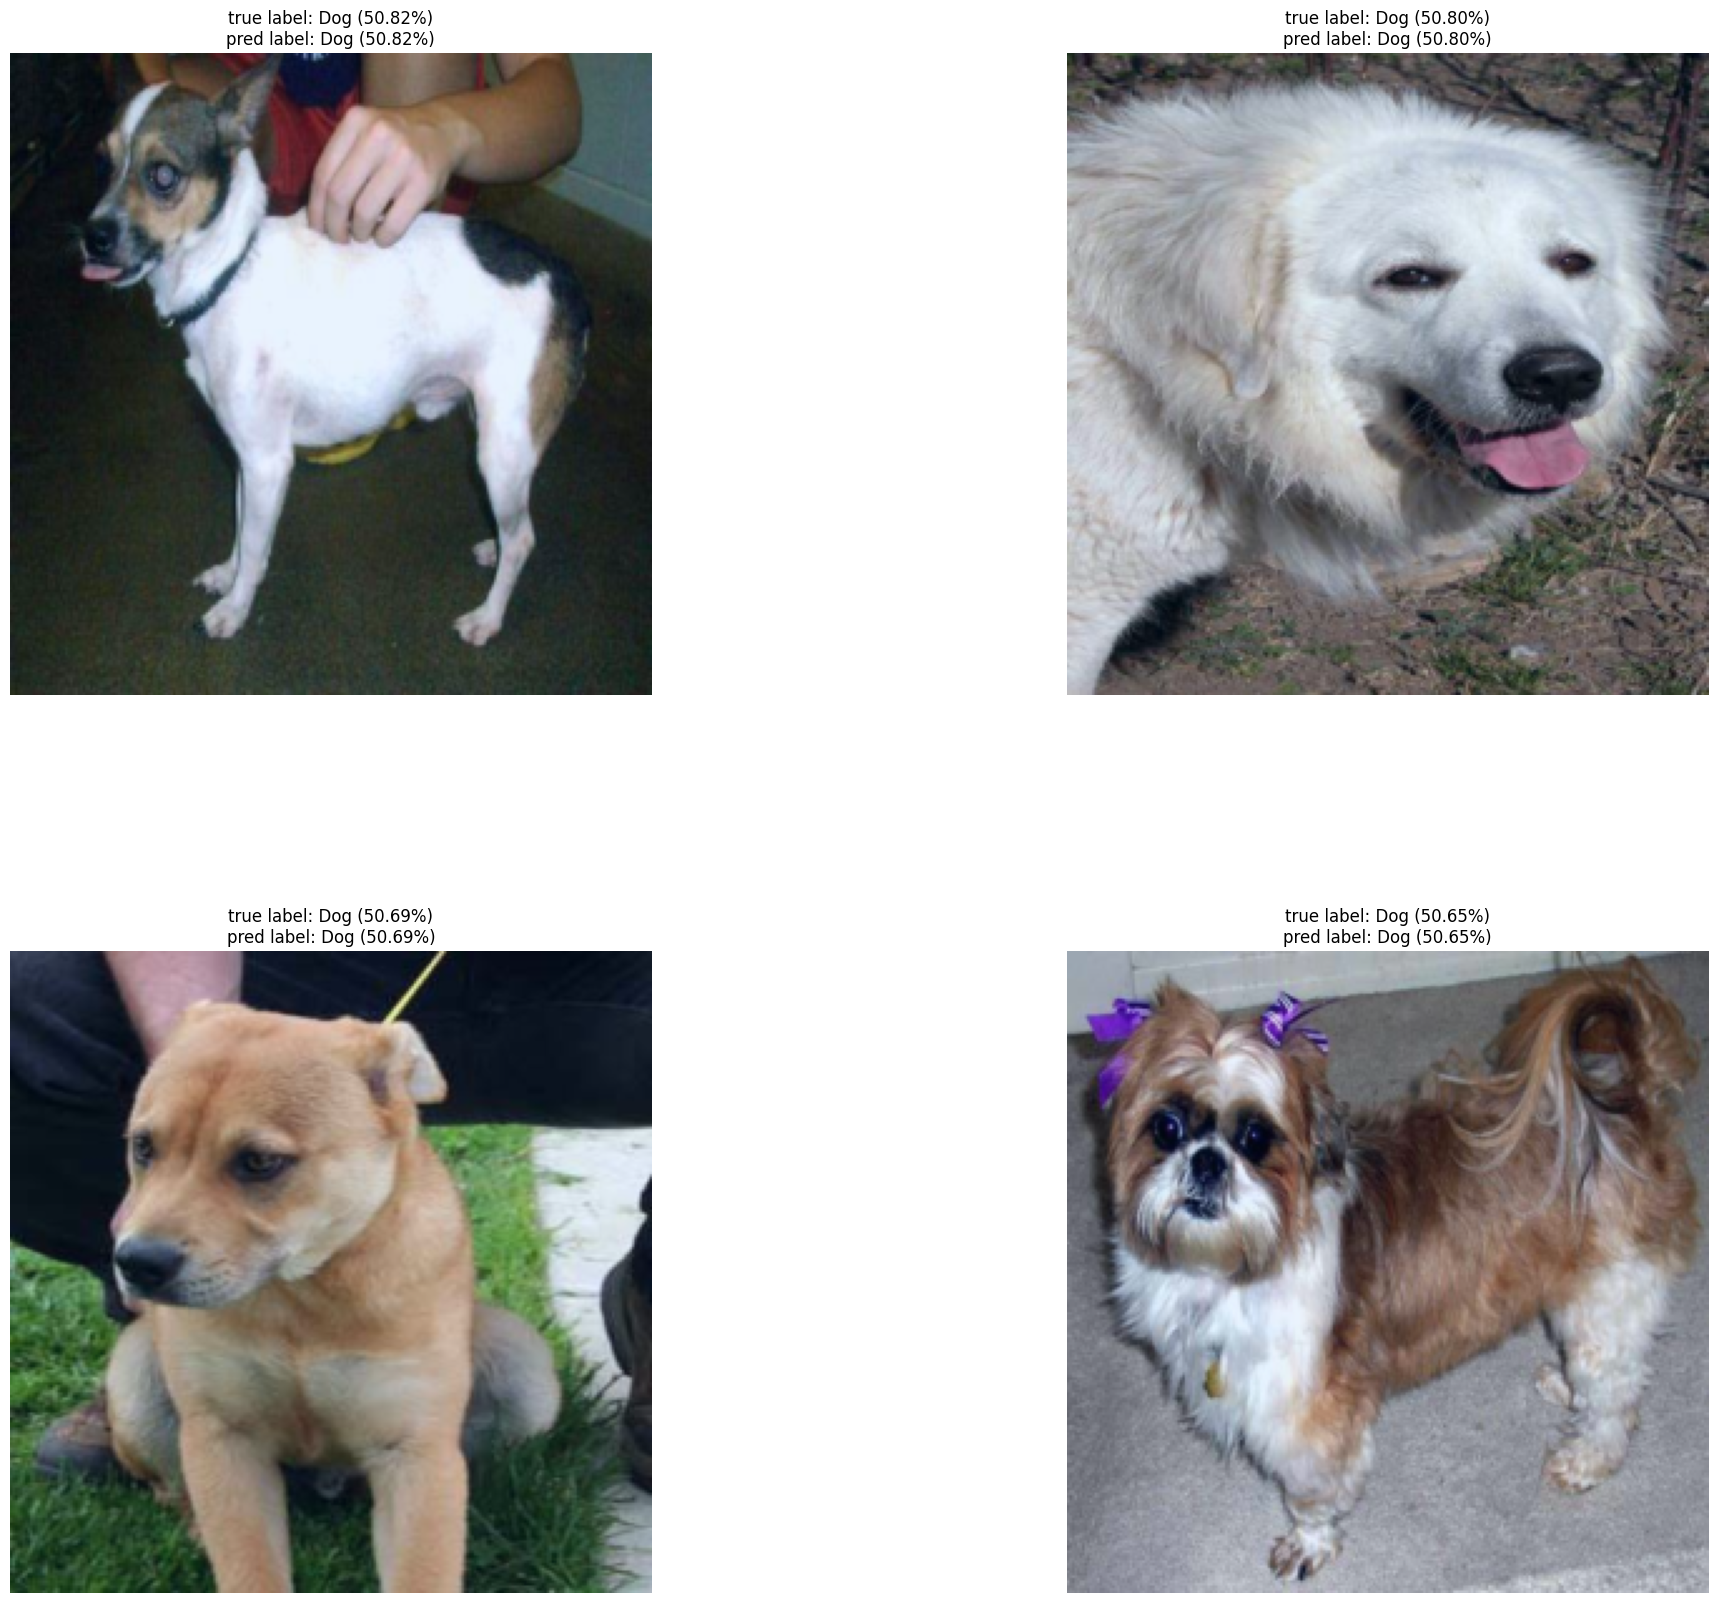

In [44]:
# 6-64 예측 결과 이미지 출력
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)